## Import Libraries

In [2]:
# Standard Library Imports
import sys
import os

# Add src/ directory to Python path to enable module imports
sys.path.append(os.path.abspath("../src"))

# Data Handling Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing Tools
from sklearn.preprocessing import LabelEncoder

# Evaluation Metrics
from sklearn.metrics import silhouette_samples, silhouette_score

# Custom Utility Functions (src/utils)
from utils import (
    save_parquet,      
    save_figure,       
    measure_time       
)

# Data Preprocessing Module (src/preprocessing)
from preprocessing import (
    get_data,             # Load dataset
    scale_features,       # Normalize/standardize features
    detect_outliers_iqr   # Detect outliers using IQR method
)

# Modeling & Clustering Module (src/modeling)
from modeling import (
    evaluate_kmeans_elbow,        
    evaluate_kmeans_silhouette,   
    run_clustering_algorithms,    
    compute_silhouette_scores,    
    run_kmedoids,               
    run_dbscan                  
)

## Data reading and preprocessing

In [3]:
# Load the dataset 
data_path = "../data/raw/renal_data.csv"
url = "https://www.dropbox.com/scl/fi/qtok6mvfmv9hflap97mla/Dataset_ExamenesLaboratorio_EnfermedadRenal.csv?rlkey=loq9xcp6r7ot06h3m7ah5ubqb&st=q1ecp0ga&dl=1"
df = get_data(path=data_path, url=url)

# Filter the records from the year 2024
dataset = df[(df['FECHA_MUESTRA'] >= 20240101) & (df['FECHA_MUESTRA'] <= 20241231)]
dataset.reset_index(drop=True, inplace=True)
dataset.head()

Loading local data...


,FECHA_CORTE,DEPARTAMENTO,PROVINCIA,DISTRITO,UBIGEO,RED,IPRESS,ID_PACIENTE,EDAD_PACIENTE,SEXO_PACIENTE,...,ACTIVIDAD_HOSPITALARIA,FECHA_MUESTRA,FEC_RESULTADO_1,PROCEDIMIENTO_1,RESULTADO_1,UNIDADES_1,FEC_RESULTADO_2,PROCEDIMIENTO_2,RESULTADO_2,UNIDADES_2
0,20240531,PIURA,PIURA,PIURA,200101,RED ASISTENCIAL PIURA,H.II JORGE REATEGUI DELGADO,eJwzNDA3MDEwsTA0MzA1NrM0MAAAHoQDZw==,63,MASCULINO,...,ATENCION MEDICA AMBULATORIA,20240102,20240112,"DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXC...",82.00,mg/dL,20240112,DOSAJE DE CREATININA EN SANGRE,12.10,mg/dL
1,20240531,MOQUEGUA,ILO,ILO,180301,RED ASISTENCIAL MOQUEGUA,H.II ILO,eJwzNLA0MTW1MDQyM7A0MzQxMgEAHx4DdA==,81,MASCULINO,...,ATENCION MEDICA AMBULATORIA,20240102,20240102,"DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXC...",74.11,mg/dL,20240102,DOSAJE DE CREATININA EN SANGRE,2.34,mg/dL
2,20240531,PIURA,PIURA,PIURA,200101,RED ASISTENCIAL PIURA,H.II JORGE REATEGUI DELGADO,eJwzNDA3NDAxNjA1MTcyMzE0MAAAHlUDXg==,55,FEMENINO,...,ATENCION MEDICA AMBULATORIA,20240102,20240108,DOSAJE DE CREATININA EN SANGRE,10.60,mg/dL,20240108,"DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXC...",135.00,mg/dL
3,20240531,PIURA,PIURA,PIURA,200101,RED ASISTENCIAL PIURA,H.II JORGE REATEGUI DELGADO,eJwzNDA3MDeyMDYzNDA3MzAwMgUAHrMDaA==,65,FEMENINO,...,ATENCION MEDICA AMBULATORIA,20240102,20240108,DOSAJE DE CREATININA EN SANGRE,6.90,mg/dL,20240108,"DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXC...",102.00,mg/dL
4,20240531,PIURA,PIURA,PIURA,200101,RED ASISTENCIAL PIURA,H.II JORGE REATEGUI DELGADO,eJwzNDA3MDMxNLQ0MTMzNrEwsQQAHtUDeg==,70,MASCULINO,...,ATENCION MEDICA AMBULATORIA,20240102,20240108,"DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXC...",110.00,mg/dL,20240108,DOSAJE DE CREATININA EN SANGRE,9.20,mg/dL


In [4]:
# Dimensions
dataset.shape

(17140, 26)

In [5]:
# Summary
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17140 entries, 0 to 17139
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   FECHA_CORTE             17140 non-null  int64  
 1   DEPARTAMENTO            17140 non-null  object 
 2   PROVINCIA               17140 non-null  object 
 3   DISTRITO                17140 non-null  object 
 4   UBIGEO                  17140 non-null  int64  
 5   RED                     17140 non-null  object 
 6   IPRESS                  17140 non-null  object 
 7   ID_PACIENTE             17140 non-null  object 
 8   EDAD_PACIENTE           17140 non-null  int64  
 9   SEXO_PACIENTE           17140 non-null  object 
 10  EDAD_MEDICO             17140 non-null  int64  
 11  ID_MEDICO               17140 non-null  object 
 12  COD_DIAG                17140 non-null  object 
 13  DIAGNOSTICO             17140 non-null  object 
 14  AREA_HOSPITALARIA       17140 non-null

In [6]:
# Duplicate values
print(dataset.duplicated().sum())

0


In [7]:
dataset["PROCEDIMIENTO_1"].value_counts()

PROCEDIMIENTO_1
DOSAJE DE CREATININA EN SANGRE                                        10790
DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXCEPTO CINTA REACTIVA)     6350
Name: count, dtype: int64

In [8]:
dataset["PROCEDIMIENTO_2"].value_counts()

PROCEDIMIENTO_2
DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXCEPTO CINTA REACTIVA)    10790
DOSAJE DE CREATININA EN SANGRE                                         6350
Name: count, dtype: int64

In [9]:
dataset["UNIDADES_1"].value_counts()

UNIDADES_1
mg/dL      17010
mmol/lt      130
Name: count, dtype: int64

In [10]:
dataset["UNIDADES_2"].value_counts()

UNIDADES_2
mg/dL      16885
mmol/lt      255
Name: count, dtype: int64

In [11]:
display(dataset[dataset['UNIDADES_1'] == 'mmol/lt'].head())

,FECHA_CORTE,DEPARTAMENTO,PROVINCIA,DISTRITO,UBIGEO,RED,IPRESS,ID_PACIENTE,EDAD_PACIENTE,SEXO_PACIENTE,...,ACTIVIDAD_HOSPITALARIA,FECHA_MUESTRA,FEC_RESULTADO_1,PROCEDIMIENTO_1,RESULTADO_1,UNIDADES_1,FEC_RESULTADO_2,PROCEDIMIENTO_2,RESULTADO_2,UNIDADES_2
235,20240531,CUSCO,CUSCO,CUSCO,80101,RED ASISTENCIAL CUSCO,H.N. ADOLFO GUEVARA VELASCO,eJwzNjKxMDQxMDU2sDA3szAyNQMAHwADeQ==,72,FEMENINO,...,ATENCION MEDICA AMBULATORIA,20240103,20240103,"DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXC...",5.46,mmol/lt,20240103,DOSAJE DE CREATININA EN SANGRE,0.77,mg/dL
664,20240531,CUSCO,CUSCO,CUSCO,80101,RED ASISTENCIAL CUSCO,H.N. ADOLFO GUEVARA VELASCO,eJwzNDU1MTc0MzUxMjY3MjI1sgQAHyEDdw==,61,MASCULINO,...,ATENCION MEDICA AMBULATORIA,20240106,20240113,"DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXC...",10.29,mmol/lt,20240113,DOSAJE DE CREATININA EN SANGRE,0.54,mg/dL
666,20240531,CUSCO,CUSCO,CUSCO,80101,RED ASISTENCIAL CUSCO,C.M. METROPOLITANO CUSCO,eJwzNDU2MjcxMjAyMzEwNzazMAQAHrwDbg==,66,FEMENINO,...,ATENCION MEDICA AMBULATORIA,20240106,20240106,"DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXC...",5.08,mmol/lt,20240106,DOSAJE DE CREATININA EN SANGRE,0.82,mg/dL
1156,20240531,CUSCO,CUSCO,CUSCO,80101,RED ASISTENCIAL CUSCO,H.N. ADOLFO GUEVARA VELASCO,eJwzNDU2NjM0Nje3NDe0MLY0MgQAH0wDfQ==,70,FEMENINO,...,ATENCION MEDICA AMBULATORIA,20240109,20240109,"DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXC...",6.52,mmol/lt,20240109,DOSAJE DE CREATININA EN SANGRE,1.19,mg/dL
1955,20240531,CUSCO,CUSCO,CUSCO,80101,RED ASISTENCIAL CUSCO,H.N. ADOLFO GUEVARA VELASCO,eJwzNDUzNDQxsDAxNbM0M7OwMAEAHyUDgw==,74,MASCULINO,...,ATENCION MEDICA AMBULATORIA,20240115,20240115,"DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXC...",4.62,mmol/lt,20240115,DOSAJE DE CREATININA EN SANGRE,2.57,mg/dL


In [12]:
# DATA ENGINEERING: FEATURE EXTRACTION AND UNIT CONVERSION

def consolidate_and_convert_laboratory_data(df):
    # Define clinical labels
    CREATININE_LABEL = 'DOSAJE DE CREATININA EN SANGRE'
    GLUCOSE_LABEL = 'DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXCEPTO CINTA REACTIVA)'

    # Initialize target columns
    df['RESULTADO_DOSAJE_CREATININA_mg/dL'] = np.nan
    df['RESULTADO_DOSAJE_GLUCOSA_mg/dL'] = np.nan

    def get_standardized_value(proc_name, result_val, unit_val):
        if pd.isna(result_val) or pd.isna(unit_val):
            return np.nan

        unit = str(unit_val).lower().strip()

        # Logic for GLUCOSE
        if proc_name == GLUCOSE_LABEL:
            if 'mmol' in unit:
                return result_val * 18.01  # Convert mmol/L to mg/dL
            return result_val  # Assume mg/dL

        # Logic for CREATININE
        if proc_name == CREATININE_LABEL:
            if 'umol' in unit:
                return result_val / 88.4   # Convert umol/L to mg/dL
            elif 'mmol' in unit:
                return result_val * 11.31  # Convert mmol/L to mg/dL (less common)
            return result_val  # Assume mg/dL

        return np.nan

    # Process Set 1
    df['VAL_1_STD'] = df.apply(lambda r: get_standardized_value(r['PROCEDIMIENTO_1'], r['RESULTADO_1'], r['UNIDADES_1']), axis=1)
    df.loc[df['PROCEDIMIENTO_1'] == CREATININE_LABEL, 'RESULTADO_DOSAJE_CREATININA_mg/dL'] = df['VAL_1_STD']
    df.loc[df['PROCEDIMIENTO_1'] == GLUCOSE_LABEL, 'RESULTADO_DOSAJE_GLUCOSA_mg/dL'] = df['VAL_1_STD']

    # Process Set 2
    df['VAL_2_STD'] = df.apply(lambda r: get_standardized_value(r['PROCEDIMIENTO_2'], r['RESULTADO_2'], r['UNIDADES_2']), axis=1)
    df.loc[df['PROCEDIMIENTO_2'] == CREATININE_LABEL, 'RESULTADO_DOSAJE_CREATININA_mg/dL'] = df.apply(
        lambda r: r['VAL_2_STD'] if pd.isna(r['RESULTADO_DOSAJE_CREATININA_mg/dL']) else r['RESULTADO_DOSAJE_CREATININA_mg/dL'], axis=1)
    df.loc[df['PROCEDIMIENTO_2'] == GLUCOSE_LABEL, 'RESULTADO_DOSAJE_GLUCOSA_mg/dL'] = df.apply(
        lambda r: r['VAL_2_STD'] if pd.isna(r['RESULTADO_DOSAJE_GLUCOSA_mg/dL']) else r['RESULTADO_DOSAJE_GLUCOSA_mg/dL'], axis=1)

    # Final cleaning
    df = df.dropna(subset=['RESULTADO_DOSAJE_CREATININA_mg/dL', 'RESULTADO_DOSAJE_GLUCOSA_mg/dL'])
    df = df[(df['RESULTADO_DOSAJE_CREATININA_mg/dL'] > 0) & (df['RESULTADO_DOSAJE_GLUCOSA_mg/dL'] > 0)]

    return df

In [13]:
# Apply the enhanced consolidation
print("Status: Consolidating and standardizing units (Target: mg/dL)...")
df_processed_ckd = consolidate_and_convert_laboratory_data(dataset.copy())

# Select relevant subset for the clustering experiment
clinical_features = [
    'ID_PACIENTE', 'EDAD_PACIENTE', 'SEXO_PACIENTE',
    'RESULTADO_DOSAJE_CREATININA_mg/dL', 'RESULTADO_DOSAJE_GLUCOSA_mg/dL', 'DIAGNOSTICO'
]
df_final = df_processed_ckd[clinical_features]

print(f"Success: Final dataset contains {df_final.shape[0]} standardized clinical records.")
df_final.head(10)

Status: Consolidating and standardizing units (Target: mg/dL)...
Success: Final dataset contains 17140 standardized clinical records.


,ID_PACIENTE,EDAD_PACIENTE,SEXO_PACIENTE,RESULTADO_DOSAJE_CREATININA_mg/dL,RESULTADO_DOSAJE_GLUCOSA_mg/dL,DIAGNOSTICO
0,eJwzNDA3MDEwsTA0MzA1NrM0MAAAHoQDZw==,63,MASCULINO,12.10,82.00,ENFERMEDAD RENAL CRONICA ESTADIO 5 EN DIALISIS
1,eJwzNLA0MTW1MDQyM7A0MzQxMgEAHx4DdA==,81,MASCULINO,2.34,74.11,ENFERMEDAD RENAL CRONICA ESTADIO 4
2,eJwzNDA3NDAxNjA1MTcyMzE0MAAAHlUDXg==,55,FEMENINO,10.60,135.00,ENFERMEDAD RENAL CRONICA ESTADIO 5 EN DIALISIS
3,eJwzNDA3MDeyMDYzNDA3MzAwMgUAHrMDaA==,65,FEMENINO,6.90,102.00,ENFERMEDAD RENAL CRONICA ESTADIO 5 EN DIALISIS
4,eJwzNDA3MDMxNLQ0MTMzNrEwsQQAHtUDeg==,70,MASCULINO,9.20,110.00,ENFERMEDAD RENAL CRONICA ESTADIO 5 EN DIALISIS
5,eJwzNDCzMDI1MjAxsDA3MrUwMQQAHs0DcA==,58,MASCULINO,3.60,117.00,ENFERMEDAD RENAL HIPERTENSIVA CON INSUFICIENCI...
6,eJwzNDA1NzEzNDSwMDQwNTa0MAEAHpMDaA==,54,FEMENINO,11.60,95.00,ENFERMEDAD RENAL CRONICA ESTADIO 5 EN DIALISIS
7,eJwzNDAzN7I0s7Q0MTY1MTGxsAQAH50Diw==,70,MASCULINO,4.10,97.74,ENFERMEDAD RENAL CRONICA ESTADIO 5 EN DIALISIS
8,eJwzNDAzNTA3MTc2NjcyMTQ3MwEAHuUDdA==,65,MASCULINO,12.40,93.00,ENFERMEDAD RENAL CRONICA ESTADIO 5 EN DIALISIS
9,eJwzNDAzNjEzsDAwNTC1MDazNAMAHsYDdw==,50,FEMENINO,12.80,88.00,ENFERMEDAD RENAL CRONICA ESTADIO 5 EN DIALISIS


In [14]:
# Checking the correct conversion
df_final.iloc[235]

ID_PACIENTE                               eJwzNjKxMDQxMDU2sDA3szAyNQMAHwADeQ==
EDAD_PACIENTE                                                               72
SEXO_PACIENTE                                                         FEMENINO
RESULTADO_DOSAJE_CREATININA_mg/dL                                         0.77
RESULTADO_DOSAJE_GLUCOSA_mg/dL                                         98.3346
DIAGNOSTICO                          ENFERMEDAD RENAL CRONICA, NO ESPECIFICADA
Name: 235, dtype: object

In [15]:
df_final["DIAGNOSTICO"].value_counts()

DIAGNOSTICO
ENFERMEDAD RENAL CRONICA ESTADIO 3                       5304
ENFERMEDAD RENAL CRONICA, NO ESPECIFICADA                4210
ENFERMEDAD RENAL CRONICA ESTADIO 5 EN DIALISIS           3065
ENFERMEDAD RENAL CRONICA ESTADIO 4                       1785
ENFERMEDAD RENAL CRONICA ESTADIO 2                       1487
ENFERMEDAD RENAL CRONICA ESTADIO 5                        742
ENFERMEDAD RENAL CRONICA ESTADIO 1                        464
ENFERMEDAD RENAL HIPERTENSIVA CON INSUFICIENCIA RENAL      74
ENFERMEDAD RENAL HIPERTENSIVA SIN INSUFICIENCIA RENAL       9
Name: count, dtype: int64

In [16]:
# Encode Gender (Female/Male -> 0/1)
def encode_categorical(df):
    le = LabelEncoder()
    df = df.copy()
    
    df['SEXO_PACIENTE_ENCODED'] = le.fit_transform(df['SEXO_PACIENTE'])
    
    return df, le

In [17]:
df_experimental, le = encode_categorical(df_final)

features_to_use = [
    'EDAD_PACIENTE',
    'SEXO_PACIENTE_ENCODED',
    'RESULTADO_DOSAJE_CREATININA_mg/dL',
    'RESULTADO_DOSAJE_GLUCOSA_mg/dL'
]

df_ckd = df_experimental[features_to_use]

print("Encoding complete")
print("Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("Shape:", df_ckd.shape)

df_ckd.head()

Encoding complete
Mapping: {'FEMENINO': 0, 'MASCULINO': 1}
Shape: (17140, 4)


,EDAD_PACIENTE,SEXO_PACIENTE_ENCODED,RESULTADO_DOSAJE_CREATININA_mg/dL,RESULTADO_DOSAJE_GLUCOSA_mg/dL
0,63,1,12.10,82.00
1,81,1,2.34,74.11
2,55,0,10.60,135.00
3,65,0,6.90,102.00
4,70,1,9.20,110.00


In [18]:
df_ckd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17140 entries, 0 to 17139
Data columns (total 4 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   EDAD_PACIENTE                      17140 non-null  int64  
 1   SEXO_PACIENTE_ENCODED              17140 non-null  int32  
 2   RESULTADO_DOSAJE_CREATININA_mg/dL  17140 non-null  float64
 3   RESULTADO_DOSAJE_GLUCOSA_mg/dL     17140 non-null  float64
dtypes: float64(2), int32(1), int64(1)
memory usage: 468.8 KB


## Data Exploration

In [19]:
# Display a description of the dataset
display(df_ckd.describe())

,EDAD_PACIENTE,SEXO_PACIENTE_ENCODED,RESULTADO_DOSAJE_CREATININA_mg/dL,RESULTADO_DOSAJE_GLUCOSA_mg/dL
count,17140.000000,17140.000000,17140.000000,17140.000000
mean,67.502042,0.532380,3.101957,110.160470
std,15.379276,0.498965,3.768895,50.104384
min,1.000000,0.000000,0.140000,8.100000
25%,60.000000,0.000000,1.080000,87.000000
50%,70.000000,1.000000,1.540000,97.000000
75%,78.000000,1.000000,3.190000,113.000000
max,103.000000,1.000000,163.520000,975.810000


In [20]:
"""
To ensure robust cluster formation, we exclude physiologically improbable values
and extreme outliers that would skew the distance metrics.
Limits defined for Outpatient Care context:
- Glucose: < 500 mg/dL (Values above often represent acute crises/errors)
- Creatinine: < 15 mg/dL (Values above are typical of acute renal failure
  rather than chronic stable profiles)
- Age: > 0 (Data integrity check)
"""

def filter(df):
    """
    Apply domain-based filtering rules
    """
    df_filtered = df[
        (df['RESULTADO_DOSAJE_GLUCOSA_mg/dL'] < 500) &
        (df['RESULTADO_DOSAJE_CREATININA_mg/dL'] < 15) &
        (df['EDAD_PACIENTE'] > 0)
    ].copy()

    return df_filtered

# Apply filters to the experimental dataframe
initial_count = len(df_ckd)

df_filtered = filter(df_ckd)

final_count = len(df_filtered)
removed = initial_count - final_count

print(f"Records before: {initial_count}")
print(f"Records after: {final_count}")
print(f"Removed: {removed} ({round((removed/initial_count)*100, 2)}%)")

data = df_filtered[features_to_use]

Records before: 17140
Records after: 16855
Removed: 285 (1.66%)


In [21]:
data.describe()

,EDAD_PACIENTE,SEXO_PACIENTE_ENCODED,RESULTADO_DOSAJE_CREATININA_mg/dL,RESULTADO_DOSAJE_GLUCOSA_mg/dL
count,16855.000000,16855.000000,16855.000000,16855.000000
mean,67.860635,0.529160,2.869979,109.438463
std,15.144143,0.499164,3.088389,44.290394
min,1.000000,0.000000,0.140000,8.100000
25%,60.000000,0.000000,1.070000,87.275000
50%,70.000000,1.000000,1.520000,97.000000
75%,78.000000,1.000000,3.000000,113.000000
max,103.000000,1.000000,14.990000,496.000000


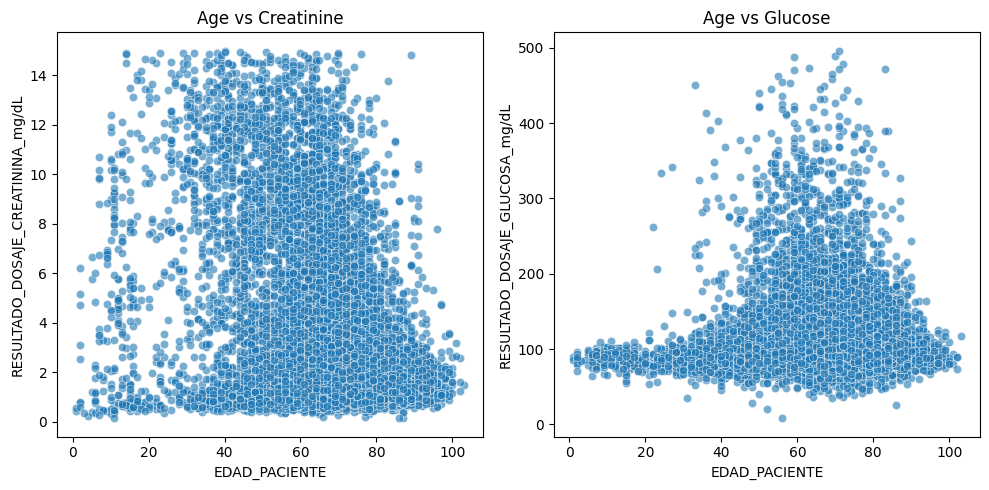

In [22]:
# Plot Age vs biomarkers

def plot_age_vs_biomarkers(data, save_path=None):
    fig = plt.figure(figsize=(10, 5))

    # Creatinine
    plt.subplot(1, 2, 1)
    sns.scatterplot(data=data, x='EDAD_PACIENTE', y='RESULTADO_DOSAJE_CREATININA_mg/dL', alpha=0.6)
    plt.title('Age vs Creatinine')

    # Glucose
    plt.subplot(1, 2, 2)
    sns.scatterplot(data=data, x='EDAD_PACIENTE', y='RESULTADO_DOSAJE_GLUCOSA_mg/dL', alpha=0.6)
    plt.title('Age vs Glucose')

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)

    return fig


fig = plot_age_vs_biomarkers(data, save_path="../outputs/figures/age_vs_biomarkers.png")

plt.show()

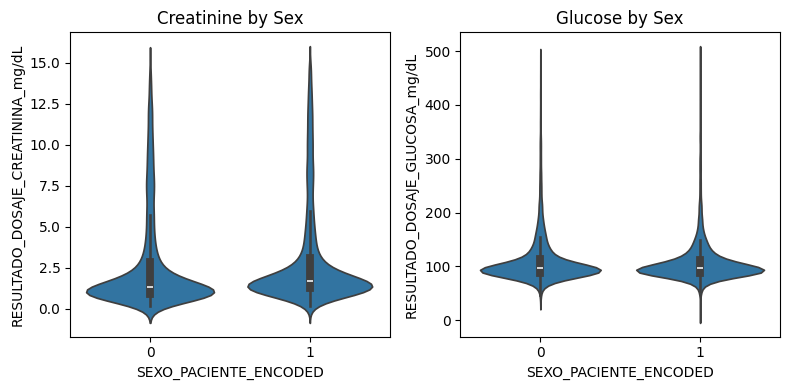

In [23]:
# Plot violin

def plot_violin_by_sex(data, save_path=None):
    fig = plt.figure(figsize=(8, 4))

    # Creatinine
    plt.subplot(1, 2, 1)
    sns.violinplot(data=data, x='SEXO_PACIENTE_ENCODED', y='RESULTADO_DOSAJE_CREATININA_mg/dL')
    plt.title('Creatinine by Sex')

    # Glucose
    plt.subplot(1, 2, 2)
    sns.violinplot(data=data, x='SEXO_PACIENTE_ENCODED', y='RESULTADO_DOSAJE_GLUCOSA_mg/dL')
    plt.title('Glucose by Sex')

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)

    return fig

fig = plot_violin_by_sex(
    data,
    save_path="../outputs/figures/violin_by_sex.png"
)

plt.show()

The violin plots show the distribution of serum creatinine and glucose levels by sex. Creatinine values tend to be slightly higher in male patients. In contrast, glucose levels show a similar distribution across sexes, with most observations concentrated around normal clinical ranges but with some extreme values indicating possible hyperglycemic conditions.

<Axes: xlabel='RESULTADO_DOSAJE_CREATININA_mg/dL', ylabel='RESULTADO_DOSAJE_GLUCOSA_mg/dL'>

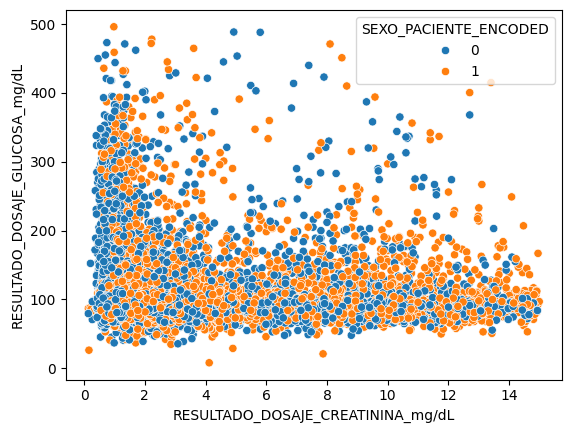

In [24]:
# Scatter plot for Glucose vs Creatinine vs Sex
sns.scatterplot(
    data=data,
    x='RESULTADO_DOSAJE_CREATININA_mg/dL',
    y='RESULTADO_DOSAJE_GLUCOSA_mg/dL',
    hue='SEXO_PACIENTE_ENCODED'
)

The scatter plot illustrates the relationship between serum creatinine and blood glucose levels. No clear separation by sex is observed, suggesting that metabolic and renal biomarkers may play a more relevant role in defining patient profiles.

## Detecting Outliers in Data

In [25]:
# Standardization
zscore_df, scaler = scale_features(data)
zscore_df.head()

,EDAD_PACIENTE,SEXO_PACIENTE_ENCODED,RESULTADO_DOSAJE_CREATININA_mg/dL,RESULTADO_DOSAJE_GLUCOSA_mg/dL
0,-0.320968,0.943285,2.988709,-0.619531
1,0.867646,0.943285,-0.171609,-0.797679
2,-0.849240,-1.060125,2.503004,0.577152
3,-0.188899,-1.060125,1.304933,-0.167953
4,0.141271,0.943285,2.049680,0.012679


In [26]:
zscore_df.dtypes

EDAD_PACIENTE                        float64
SEXO_PACIENTE_ENCODED                float64
RESULTADO_DOSAJE_CREATININA_mg/dL    float64
RESULTADO_DOSAJE_GLUCOSA_mg/dL       float64
dtype: object

In [27]:
# Save processed data
processed_path = "../data/processed/renal_disease_final.parquet"

save_parquet(zscore_df, processed_path)

print(f"Data saved successfully at: {processed_path}")

Data saved successfully at: ../data/processed/renal_disease_final.parquet


In [28]:
# Outlier detection
Data_SO, Data_CO = detect_outliers_iqr(zscore_df)
print(Data_SO.shape,Data_CO.shape)

(12690, 4) (4165, 4)


## **Unsupervised Algorithms**

###  K-means

In [29]:
# Elbow Method for K-Means Clustering
results = evaluate_kmeans_elbow(Data_SO)

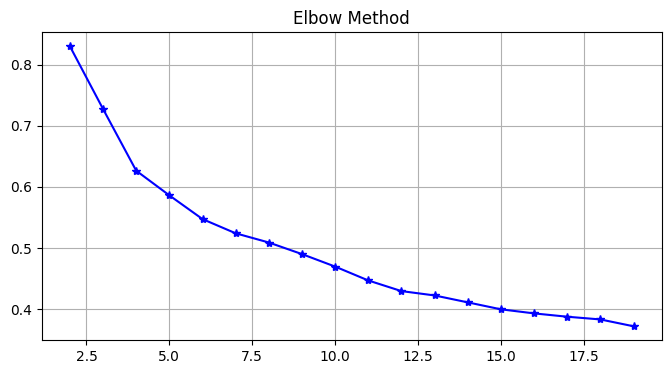

In [30]:
# Define the range of clusters to evaluate
K = range(2, 20)
fig1 = plt.figure(figsize=(8,4))
plt.plot(K, results["avgWithinSS"], 'b*-')
plt.title('Elbow Method')
plt.grid(True)

save_figure(fig1, "../outputs/figures/elbow_method.png")

plt.show()

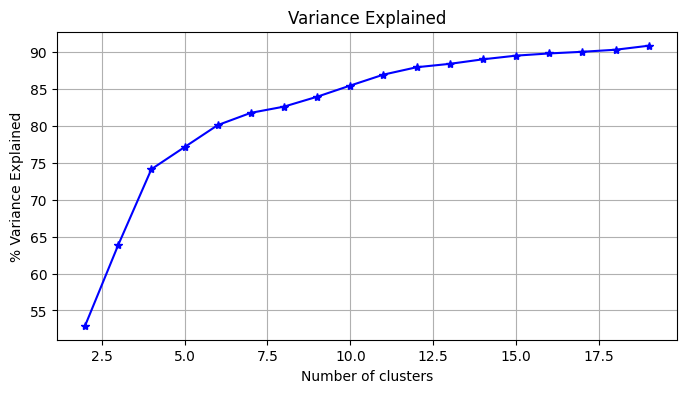

In [31]:
# Variance Explained
# Define the range of clusters to evaluate
K = range(2, 20)
fig2=plt.figure(figsize=(8,4))
plt.plot(K, results["bss_ratio"], 'b*-')
plt.xlabel('Number of clusters')
plt.ylabel('% Variance Explained')
plt.title('Variance Explained')
plt.grid()

save_figure(fig2, "../outputs/figures/variance_explained.png")
plt.show()

In [32]:
# Silhouette Score for K-Means Clustering
results_sil = evaluate_kmeans_silhouette(Data_SO)

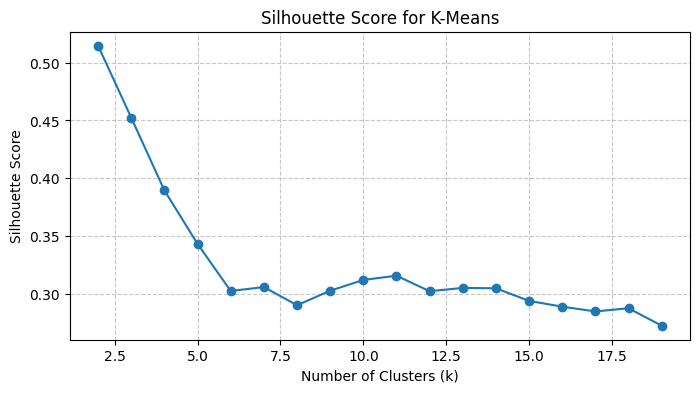

In [33]:
K = results_sil["k_values"]
scores = results_sil["silhouette_scores"]

fig3=plt.figure(figsize=(8,4))
plt.plot(K, scores, marker='o')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylabel("Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.title("Silhouette Score for K-Means")

save_figure(fig3, "../outputs/figures/silhouette_score.png")

plt.show()

The elbow method was applied to determine the optimal number of clusters. The curve shows a significant decrease in the within-cluster sum of squares between 2 and 6 clusters. In other hand, the percentage of variance explained by the clustering structure increases as the number of clusters grows. However, after approximately 5 clusters, the improvement becomes marginal. Combined with the elbow method results and silhouette score, this suggests that K=5 provides a suitable balance.

## Comparison of clustering algorithms (KMeans, Hierarchical (Agglomerative), DBSCAN)

In [34]:
# Clustering algorithms
results = run_clustering_algorithms(Data_SO, k_clusters=5)

#### *Metrics*

In [35]:
silhouette_scores = compute_silhouette_scores(Data_SO.values, results)
silhouette_scores.to_csv("../outputs/results/silhouette_scores.csv", index=False)
silhouette_scores

,algorithm,silhouette_score
0,kmeans,0.343363
1,hierarchical,0.324867
2,dbscan,0.492017


## PAM (Partitioning Around Medoids)

In [36]:
labels_kmed, exec_time = measure_time(
    run_kmedoids,
    Data_SO.values,
    [3, 6, 4, 10, 11]
)

score_pam = silhouette_score(Data_SO.values, labels_kmed)

df_score_pam = pd.DataFrame({'metric': ['pam_silhouette_score'], 'value': [score_pam]})
df_score_pam.to_csv("../outputs/results/pam_silhouette_score.csv", index=False)

print("Silhouette score PAM:", score_pam)
print("Time:", exec_time)

Silhouette score PAM: 0.3542750344219286
Time: 169.03243136405945


The Silhouette score was used to evaluate the clustering performance of the applied algorithms. Among the evaluated methods, DBSCAN achieved the highest score (0.492), suggesting a better separation and cohesion of clusters compared to K-Means (0.343), Hierarchical Clustering (0.325), and PAM (0.354).

In [37]:
# Reset the index
Data_SO.reset_index(inplace=True)
Data_CO.reset_index(inplace=True)
Data_SO

,index,EDAD_PACIENTE,SEXO_PACIENTE_ENCODED,RESULTADO_DOSAJE_CREATININA_mg/dL,RESULTADO_DOSAJE_GLUCOSA_mg/dL
0,1,0.867646,0.943285,-0.171609,-0.797679
1,5,-0.651138,0.943285,0.236383,0.170731
2,7,0.141271,0.943285,0.398284,-0.264139
3,15,-0.651138,-1.060125,0.463045,-0.416321
4,16,0.669544,-1.060125,-0.735026,0.229130
...,...,...,...,...,...
12685,17133,1.065748,0.943285,-0.356177,-0.574373
12686,17134,0.405407,-1.060125,-0.181323,0.531994
12687,17136,-0.453036,0.943285,-0.433889,-0.009900
12688,17137,1.924191,-1.060125,-0.579601,-0.642110


## Fit the DBSCAN model to the dataset without outliers

In [38]:
# # Remove the unnecessary column created by reset_index
# This ensures that only the relevant variables are used for clustering
Data_SO_ = Data_SO.drop(['index'], axis=1)

# Model
labels = run_dbscan(Data_SO_.values, eps=0.6)

# Post-processing
PERFIL = pd.DataFrame({'PERFIL': labels})

data_SO1 = pd.concat(
    [Data_SO.reset_index(drop=True), PERFIL],
    axis=1
)

data_SO1.head()

,index,EDAD_PACIENTE,SEXO_PACIENTE_ENCODED,RESULTADO_DOSAJE_CREATININA_mg/dL,RESULTADO_DOSAJE_GLUCOSA_mg/dL,PERFIL
0,1,0.867646,0.943285,-0.171609,-0.797679,0
1,5,-0.651138,0.943285,0.236383,0.170731,0
2,7,0.141271,0.943285,0.398284,-0.264139,0
3,15,-0.651138,-1.060125,0.463045,-0.416321,1
4,16,0.669544,-1.060125,-0.735026,0.229130,1


In [39]:
data_SO1.shape

(12690, 6)

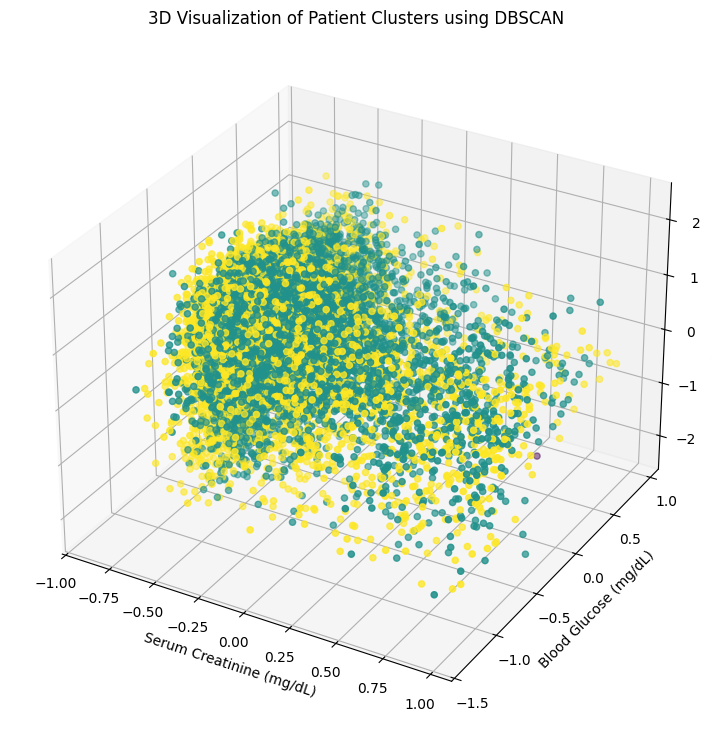

In [40]:
# Set the size of the figure for better visualization
plt.rcParams['figure.figsize'] = (13, 9)

# Add a 3D subplot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Create a 3D scatter plot
ax.scatter(
    data_SO1['RESULTADO_DOSAJE_CREATININA_mg/dL'],
    data_SO1['RESULTADO_DOSAJE_GLUCOSA_mg/dL'],
    data_SO1['EDAD_PACIENTE'],
    c=data_SO1['PERFIL']
)

# Label the axes
ax.set_xlabel('Serum Creatinine (mg/dL)')
ax.set_ylabel('Blood Glucose (mg/dL)')
ax.set_zlabel('Patient Age')

# Add a title
ax.set_title('3D Visualization of Patient Clusters using DBSCAN')
plt.show()

## Outliter reassignment

In [41]:
# Data with outliers
Data_CO.head()

,index,EDAD_PACIENTE,SEXO_PACIENTE_ENCODED,RESULTADO_DOSAJE_CREATININA_mg/dL,RESULTADO_DOSAJE_GLUCOSA_mg/dL
0,0,-0.320968,0.943285,2.988709,-0.619531
1,2,-0.849240,-1.060125,2.503004,0.577152
2,3,-0.188899,-1.060125,1.304933,-0.167953
3,4,0.141271,0.943285,2.049680,0.012679
4,6,-0.915274,-1.060125,2.826807,-0.326005


In [42]:
# Remove the unnecessary index column
Data_CO_ = Data_CO.drop(['index'], axis=1)

# Model
labels = run_dbscan(Data_CO_.values, eps=0.6)

# Post-processing
PERFIL = pd.DataFrame({'PERFIL': labels})

Data_CO1 = pd.concat(
    [Data_CO.reset_index(drop=True), PERFIL],
    axis=1
)

Data_CO1.head()

,index,EDAD_PACIENTE,SEXO_PACIENTE_ENCODED,RESULTADO_DOSAJE_CREATININA_mg/dL,RESULTADO_DOSAJE_GLUCOSA_mg/dL,PERFIL
0,0,-0.320968,0.943285,2.988709,-0.619531,0
1,2,-0.849240,-1.060125,2.503004,0.577152,1
2,3,-0.188899,-1.060125,1.304933,-0.167953,1
3,4,0.141271,0.943285,2.049680,0.012679,0
4,6,-0.915274,-1.060125,2.826807,-0.326005,1


In [43]:
Data_CO1.shape

(4165, 6)

In [44]:
# Concatenate
DATA_PERFIL_STAN = pd.concat([data_SO1, Data_CO1])
DATA_PERFIL_STAN.head()

,index,EDAD_PACIENTE,SEXO_PACIENTE_ENCODED,RESULTADO_DOSAJE_CREATININA_mg/dL,RESULTADO_DOSAJE_GLUCOSA_mg/dL,PERFIL
0,1,0.867646,0.943285,-0.171609,-0.797679,0
1,5,-0.651138,0.943285,0.236383,0.170731,0
2,7,0.141271,0.943285,0.398284,-0.264139,0
3,15,-0.651138,-1.060125,0.463045,-0.416321,1
4,16,0.669544,-1.060125,-0.735026,0.229130,1


In [45]:
DATA_PERFIL_STAN.shape

(16855, 6)

In [46]:
df_ckd.head()

,EDAD_PACIENTE,SEXO_PACIENTE_ENCODED,RESULTADO_DOSAJE_CREATININA_mg/dL,RESULTADO_DOSAJE_GLUCOSA_mg/dL
0,63,1,12.10,82.00
1,81,1,2.34,74.11
2,55,0,10.60,135.00
3,65,0,6.90,102.00
4,70,1,9.20,110.00


In [47]:
# Reset the index
df_ckd.reset_index(inplace=True)
df_ckd.head()

,index,EDAD_PACIENTE,SEXO_PACIENTE_ENCODED,RESULTADO_DOSAJE_CREATININA_mg/dL,RESULTADO_DOSAJE_GLUCOSA_mg/dL
0,0,63,1,12.10,82.00
1,1,81,1,2.34,74.11
2,2,55,0,10.60,135.00
3,3,65,0,6.90,102.00
4,4,70,1,9.20,110.00


In [48]:
#  Merge the original dataset with the cluster labels
DATA_PERFIL_FINAL = pd.merge(df_ckd,DATA_PERFIL_STAN[['index','PERFIL']],on=['index'],how='inner')
DATA_PERFIL_FINAL.head()

,index,EDAD_PACIENTE,SEXO_PACIENTE_ENCODED,RESULTADO_DOSAJE_CREATININA_mg/dL,RESULTADO_DOSAJE_GLUCOSA_mg/dL,PERFIL
0,0,63,1,12.10,82.00,0
1,1,81,1,2.34,74.11,0
2,2,55,0,10.60,135.00,1
3,3,65,0,6.90,102.00,1
4,4,70,1,9.20,110.00,0


In [49]:
DATA_PERFIL_FINAL["PERFIL"].value_counts()

PERFIL
 0    8843
 1    7848
-1     132
 3       9
 6       6
 2       6
 5       6
 4       5
Name: count, dtype: int64

## Profile descriptions

In [50]:
# Remove the auxiliary index column
DESCRIPTIONS_ = DATA_PERFIL_FINAL.drop(columns=['index'])

# Compute mean values for each cluster
cluster_profile = DESCRIPTIONS_.groupby('PERFIL').mean()

# Compute percentage of patients in each cluster
cluster_percentage = (
    DATA_PERFIL_FINAL['PERFIL']
    .value_counts(normalize=True)
    .sort_index()
    * 100
).to_frame(name='PERCENTAGE')

# Combine cluster percentage with cluster profiles
DESCRIPTIONS_FINAL = pd.concat([cluster_percentage, cluster_profile], axis=1)

# Convert encoded sex variable into percentage of male patients
DESCRIPTIONS_FINAL['MALE_%'] = DESCRIPTIONS_FINAL['SEXO_PACIENTE_ENCODED'] * 100

# Drop the encoded sex column
DESCRIPTIONS_FINAL = DESCRIPTIONS_FINAL.drop(columns=['SEXO_PACIENTE_ENCODED'])

# Rename columns
DESCRIPTIONS_FINAL = DESCRIPTIONS_FINAL.rename(columns={
    'EDAD_PACIENTE': 'AVG_AGE',
    'RESULTADO_DOSAJE_CREATININA_mg/dL': 'AVG_CREATININE',
    'RESULTADO_DOSAJE_GLUCOSA_mg/dL': 'AVG_GLUCOSE'
})

# Presentation
DESCRIPTIONS_FINAL = DESCRIPTIONS_FINAL.round(3)
DESCRIPTIONS_FINAL = DESCRIPTIONS_FINAL.sort_values(by='PERCENTAGE', ascending=False)
DESCRIPTIONS_FINAL

,PERCENTAGE,AVG_AGE,AVG_CREATININE,AVG_GLUCOSE,MALE_%
PERFIL,,,,,
0,52.465,69.067,2.994,106.845,100.000
1,46.562,66.732,2.654,109.121,0.000
-1,0.783,54.917,6.379,288.133,48.485
3,0.053,74.111,1.578,42.263,0.000
2,0.036,65.000,2.310,41.257,100.000
5,0.036,57.333,12.543,220.725,100.000
6,0.036,60.500,10.390,337.020,0.000
4,0.030,62.600,11.136,272.760,0.000


The clustering results obtained using the DBSCAN reveal that the dataset is mainly composed of two dominant patient profiles (Profile 0 and Profile 1), representing approximately 52% and 46% of the population respectively. Both groups show very similar clinical characteristics, with an average age of about 67 years, creatinine levels around 3.1 mg/dL, and glucose levels close to 110 mg/dL. Additionally, the gender distribution is balanced, with approximately 53% male patients.

The label -1 corresponds to noise points identified by DBSCAN. These represent approximately 0.78% of the dataset and correspond to patients whose characteristics differ significantly from the main clusters. These cases may represent outliers or rare clinical conditions.

In [51]:
DATA_PERFIL_FINAL

,index,EDAD_PACIENTE,SEXO_PACIENTE_ENCODED,RESULTADO_DOSAJE_CREATININA_mg/dL,RESULTADO_DOSAJE_GLUCOSA_mg/dL,PERFIL
0,0,63,1,12.10,82.00,0
1,1,81,1,2.34,74.11,0
2,2,55,0,10.60,135.00,1
3,3,65,0,6.90,102.00,1
4,4,70,1,9.20,110.00,0
...,...,...,...,...,...,...
16850,17135,59,0,1.16,170.49,1
16851,17136,61,1,1.53,109.00,0
16852,17137,97,0,1.08,81.00,1
16853,17138,67,0,11.00,109.00,1


In [52]:
# Data profile final
DATA_PERFIL_FINAL_ID = pd.merge(
    DATA_PERFIL_FINAL,
    df_final.reset_index()[['index','ID_PACIENTE']],
    on='index',
    how='left'
)

DATA_PERFIL_FINAL_ID = DATA_PERFIL_FINAL_ID[
[
'ID_PACIENTE',
'EDAD_PACIENTE',
'SEXO_PACIENTE_ENCODED',
'RESULTADO_DOSAJE_CREATININA_mg/dL',
'RESULTADO_DOSAJE_GLUCOSA_mg/dL',
'PERFIL'
]]

DATA_PERFIL_FINAL_ID.head()

,ID_PACIENTE,EDAD_PACIENTE,SEXO_PACIENTE_ENCODED,RESULTADO_DOSAJE_CREATININA_mg/dL,RESULTADO_DOSAJE_GLUCOSA_mg/dL,PERFIL
0,eJwzNDA3MDEwsTA0MzA1NrM0MAAAHoQDZw==,63,1,12.10,82.00,0
1,eJwzNLA0MTW1MDQyM7A0MzQxMgEAHx4DdA==,81,1,2.34,74.11,0
2,eJwzNDA3NDAxNjA1MTcyMzE0MAAAHlUDXg==,55,0,10.60,135.00,1
3,eJwzNDA3MDeyMDYzNDA3MzAwMgUAHrMDaA==,65,0,6.90,102.00,1
4,eJwzNDA3MDMxNLQ0MTMzNrEwsQQAHtUDeg==,70,1,9.20,110.00,0


## Distribution of original diagnoses within each profile

In [55]:
# Merge the final patient profiles with their original diagnoses
profile_diagnoses = pd.merge(
    DATA_PERFIL_FINAL_ID,
    df_final[['ID_PACIENTE', 'DIAGNOSTICO']],
    on='ID_PACIENTE',
    how='left'
)

# Analyze the distribution of diagnoses within each profile
diagnosis_distribution = profile_diagnoses.groupby('PERFIL')['DIAGNOSTICO'].value_counts(normalize=True).mul(100).unstack(fill_value=0)

#Save the results
diagnosis_distribution.to_csv("../outputs/results/cluster_diagnosis_profile.csv", index=False)

# Display the results
print("Distribution of Diagnoses within Each Patient Profile (in %):")
display(diagnosis_distribution.round(2))

Distribution of Diagnoses within Each Patient Profile (in %):


DIAGNOSTICO,ENFERMEDAD RENAL CRONICA ESTADIO 1,ENFERMEDAD RENAL CRONICA ESTADIO 2,ENFERMEDAD RENAL CRONICA ESTADIO 3,ENFERMEDAD RENAL CRONICA ESTADIO 4,ENFERMEDAD RENAL CRONICA ESTADIO 5,ENFERMEDAD RENAL CRONICA ESTADIO 5 EN DIALISIS,"ENFERMEDAD RENAL CRONICA, NO ESPECIFICADA",ENFERMEDAD RENAL HIPERTENSIVA CON INSUFICIENCIA RENAL,ENFERMEDAD RENAL HIPERTENSIVA SIN INSUFICIENCIA RENAL
PERFIL,,,,,,,,,
-1,0.78,1.94,5.43,3.49,1.16,74.03,10.85,2.33,0.00
0,1.57,6.90,30.07,11.52,5.55,24.30,19.54,0.49,0.06
1,2.80,7.39,26.33,11.32,5.29,25.57,20.91,0.37,0.02
2,16.67,0.00,16.67,16.67,0.00,33.33,16.67,0.00,0.00
3,0.00,33.33,33.33,22.22,0.00,0.00,11.11,0.00,0.00
4,0.00,0.00,0.00,0.00,0.00,78.57,7.14,14.29,0.00
5,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00
6,0.00,0.00,0.00,0.00,0.00,66.67,4.76,28.57,0.00


Each cell shows the percentage of patients within a given profile (row) that have a specific diagnosis (column). The sum of percentages across a row (for a given profile) will add up to 100%. The -1 profile contains outliers. By examining their diagnostic distribution, you can see if these outliers correspond to particularly rare diagnoses, or if they are a mix of diagnoses but with unusual laboratory values that made them not fit into the main clusters.

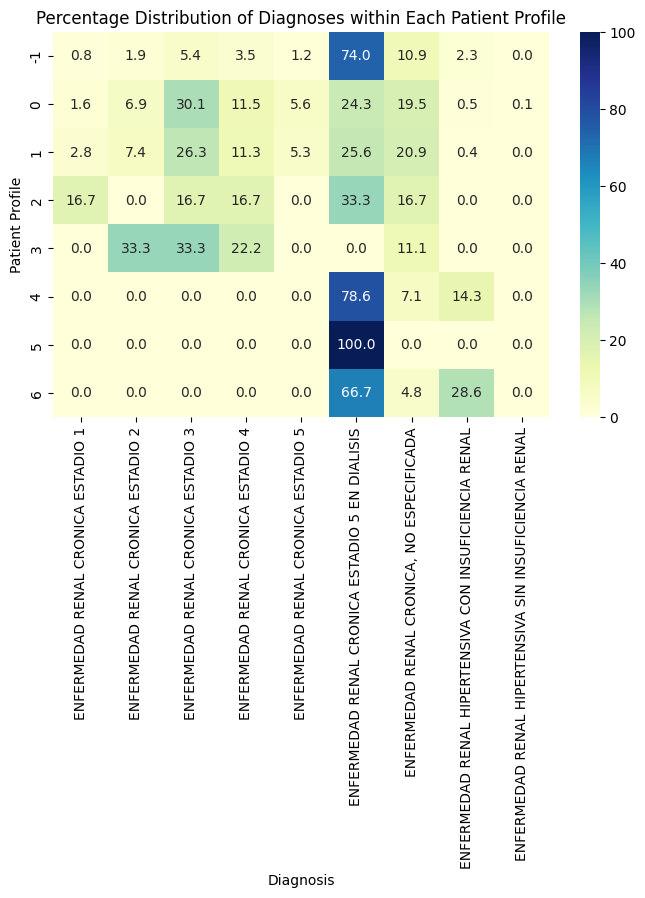

In [54]:
# Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(diagnosis_distribution, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Percentage Distribution of Diagnoses within Each Patient Profile')
plt.xlabel('Diagnosis')
plt.ylabel('Patient Profile')
plt.show()

# RESULTS AND DISCUSSION
Several clustering algorithms were evaluated to identify patterns among patients, including K-Means Clustering, hierarchical clustering, PAM (K-Medoids), and DBSCAN. Model performance was compared using the Silhouette Score. Among the evaluated methods, DBSCAN obtained the highest silhouette score (0.49), indicating better cluster separation and compactness. Therefore, DBSCAN was selected as the final model to identify patient profiles.

The clustering results revealed two dominant patient profiles representing approximately 52% and 46% of the dataset. Both profiles show very similar characteristics, with an average age close to 67 years, creatinine levels around 3.1 mg/dL, and glucose levels near 110 mg/dL. The gender distribution is also balanced, with approximately 53% male patients in both groups. These results suggest that the patient population is relatively homogeneous with respect to the analyzed variables. Additionally, DBSCAN identified a small proportion of observations labeled as -1, which correspond to outliers. These cases represent less than 1% of the dataset and may correspond to unusual clinical conditions or atypical measurements.

## CONCLUSIONS
This study applied several unsupervised learning techniques to explore patterns among patients using clinical variables such as age, creatinine levels, glucose levels, and gender. The results revealed two main patient profiles with similar clinical characteristics, suggesting that the population is relatively homogeneous with respect to the analyzed variables. A small proportion of observations were also identified as outliers.

A limitation of this study is the use of a limited set of variables, which may restrict the ability of the clustering model to detect more distinct patient subgroups. Future work could incorporate additional clinical variables and explore alternative modeling approaches to better understand patient profiles and their relationship with medical diagnoses.

# REFERENCES

Baishya, R., & Mazumdar, A. (2025). Evaluating kidney function and body composition: The role of creatinine metabolism in clinical practice. *International Journal of Current Pharmaceutical Review and Research, 17*(4), 527–551.

Levey, A. S., & Coresh, J. (2012). Chronic kidney disease. *The lancet, 379*(9811), 165-180.

Vilchis, M. A. T. (2026). Diabetes silenciosa: el enemigo a vencer. *Archivos en Medicina Familiar, 28*(1), 57-60.